# Customer Support Intelligence Platform — Phase 1: Exploratory Data Analysis

**Brief requirements covered in this notebook (Day 3-4):**
- Analyse Ticket Type and Priority distributions
- Visualise Customer Satisfaction Ratings, Resolution Time distribution, Channel breakdown
- Word clouds of Ticket Description and Ticket Subject
- Identify class imbalance in Ticket Type and Ticket Priority
- Document insights in markdown cells

**Tooling note:** using Matplotlib and Seaborn only (both explicitly listed as
acceptable in the brief) - not Plotly, to match available skillset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("C:\\Users\\CHARU\\OneDrive\\Desktop\\Final Project\\data_raw\\customer_support_tickets.csv")
print(f"Shape: {df.shape}")
df.head(3)

Shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


## 1. Data quality check: the missingness pattern

**Important finding to document upfront:** `Resolution`, `Time to Resolution`, and
`Customer Satisfaction Rating` are all missing for the exact same 5,700 rows (67% of
the dataset). This isn't random missing data - it's because these fields only exist
for **closed** tickets. Any analysis or modeling using these columns must explicitly
account for this, rather than silently dropping rows or imputing values that would
misrepresent open tickets as if they had resolution data.

In [4]:
print("Ticket Status breakdown:")
print(df["Ticket Status"].value_counts())
print()

missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])
print()

# Confirm the hypothesis: missingness in these 3 columns should exactly match
# non-Closed tickets
non_closed = (df["Ticket Status"] != "Closed").sum()
print(f"Non-Closed tickets: {non_closed}")
print(f"Missing 'Time to Resolution': {df['Time to Resolution'].isnull().sum()}")
print("These should match if our hypothesis is correct:", non_closed == df["Time to Resolution"].isnull().sum())

Ticket Status breakdown:
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

Missing values per column:
Resolution                      5700
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Non-Closed tickets: 5700
Missing 'Time to Resolution': 5700
These should match if our hypothesis is correct: True


## 2. Ticket Type distribution

**Note on the brief's specification:** the brief describes 4 Ticket Type categories
(Billing / Technical / Account / Product Inquiry), but the actual dataset contains
**5 categories**: Refund request, Technical issue, Cancellation request, Product
inquiry, Billing inquiry. We proceed with the real 5 categories found in the data -
building for 4 categories that don't exist would mean silently dropping ~40% of
the data (Refund + Cancellation requests have no equivalent in the brief's 4-category
list).

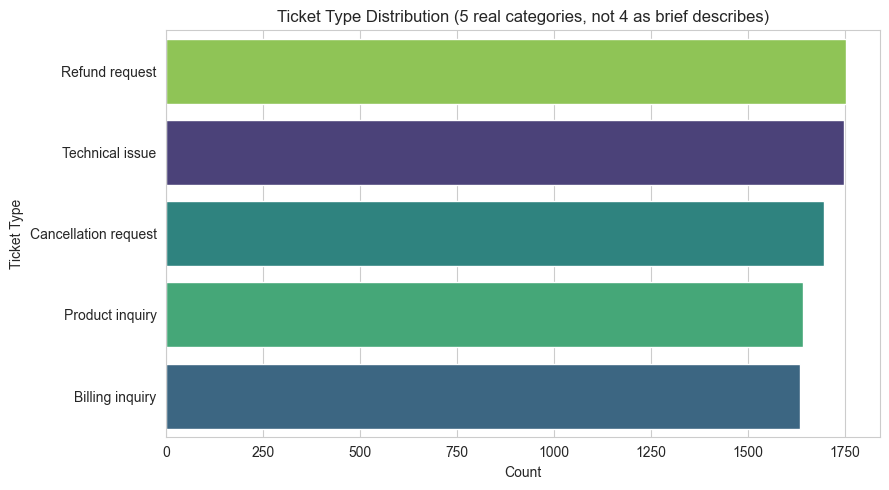

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Class balance check - min/max ratio: 0.933
(1.0 = perfectly balanced; this is close to balanced, good news for classification)


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df["Ticket Type"].value_counts().index
sns.countplot(data=df, y="Ticket Type", order=order, hue="Ticket Type", ax=ax, palette="viridis", legend=False)
ax.set_title("Ticket Type Distribution (5 real categories, not 4 as brief describes)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("../reports/eda_ticket_type_distribution.png", dpi=120)
plt.show()

print(df["Ticket Type"].value_counts())
print(f"\nClass balance check - min/max ratio: {df['Ticket Type'].value_counts().min() / df['Ticket Type'].value_counts().max():.3f}")
print("(1.0 = perfectly balanced; this is close to balanced, good news for classification)")

## 3. Ticket Priority distribution

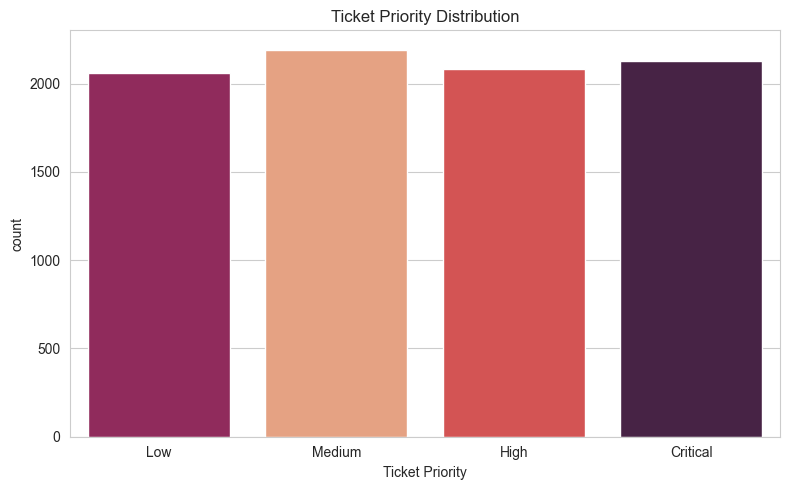

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Class balance check - min/max ratio: 0.941
Also close to balanced - good, means we won't need heavy class-weighting for this task.


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
priority_order = ["Low", "Medium", "High", "Critical"]
sns.countplot(data=df, x="Ticket Priority", order=priority_order, hue="Ticket Priority", ax=ax, palette="rocket", legend=False)
ax.set_title("Ticket Priority Distribution")
plt.tight_layout()
plt.savefig("../reports/eda_ticket_priority_distribution.png", dpi=120)
plt.show()

print(df["Ticket Priority"].value_counts())
print(f"\nClass balance check - min/max ratio: {df['Ticket Priority'].value_counts().min() / df['Ticket Priority'].value_counts().max():.3f}")
print("Also close to balanced - good, means we won't need heavy class-weighting for this task.")

## 4. Customer Satisfaction Rating

**Only available for closed tickets (2,769 rows)** - analyzing the full dataset
here would be misleading since 67% of rows have no rating at all.

Closed tickets (the only ones with satisfaction ratings): 2769


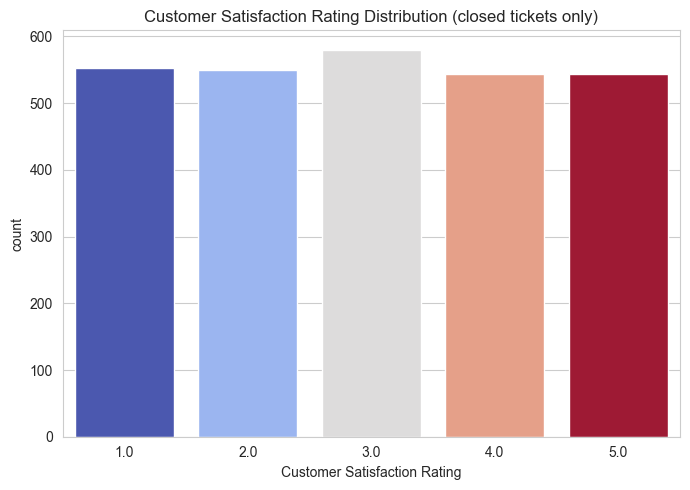

Customer Satisfaction Rating
1.0    553
2.0    549
3.0    580
4.0    543
5.0    544
Name: count, dtype: int64

Mean satisfaction: 2.99 / 5


In [7]:
closed_df = df[df["Ticket Status"] == "Closed"].copy()
print(f"Closed tickets (the only ones with satisfaction ratings): {len(closed_df)}")

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=closed_df, x="Customer Satisfaction Rating", hue="Customer Satisfaction Rating", ax=ax, palette="coolwarm", legend=False)
ax.set_title("Customer Satisfaction Rating Distribution (closed tickets only)")
plt.tight_layout()
plt.savefig("../reports/eda_satisfaction_distribution.png", dpi=120)
plt.show()

print(closed_df["Customer Satisfaction Rating"].value_counts().sort_index())
print(f"\nMean satisfaction: {closed_df['Customer Satisfaction Rating'].mean():.2f} / 5")

## 5. Time to Resolution distribution

Also closed-tickets-only. Need to parse this from timestamp strings first (First
Response Time and Time to Resolution are stored as datetime strings, not numeric
hours - despite the brief calling it a "continuous, in hours" target, so we compute
that ourselves).

count    2769.000000
mean       -0.057704
std         9.564112
min       -23.233333
25%        -6.933333
50%         0.166667
75%         6.483333
max        23.466667
Name: Resolution Hours, dtype: float64


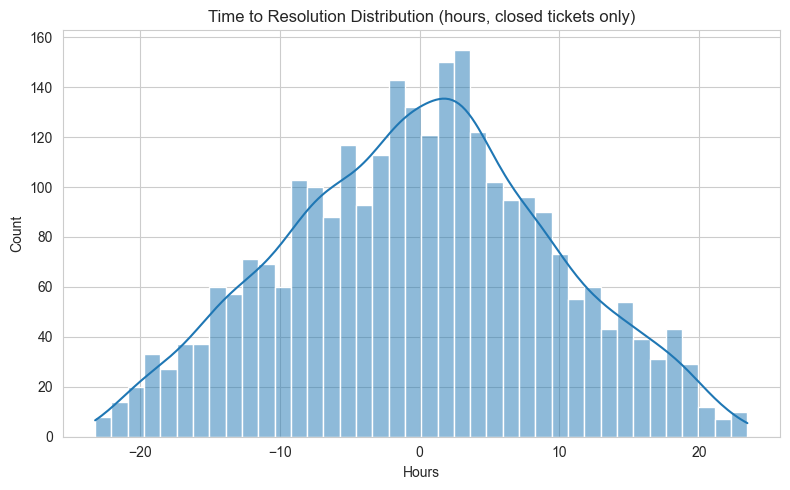


Rows with negative resolution time (data quality issue - resolution before first response): 1365
These will need to be filtered out or investigated before the regression task.


In [8]:
# The brief's data dictionary describes 'Time to Resolution' as hours, but the raw
# column is actually a timestamp string. We compute actual resolution duration in
# hours by comparing First Response Time to Time to Resolution timestamps.
closed_df["First Response Time"] = pd.to_datetime(closed_df["First Response Time"])
closed_df["Time to Resolution"] = pd.to_datetime(closed_df["Time to Resolution"])
closed_df["Resolution Hours"] = (closed_df["Time to Resolution"] - closed_df["First Response Time"]).dt.total_seconds() / 3600

print(closed_df["Resolution Hours"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(closed_df["Resolution Hours"], bins=40, kde=True, ax=ax)
ax.set_title("Time to Resolution Distribution (hours, closed tickets only)")
ax.set_xlabel("Hours")
plt.tight_layout()
plt.savefig("../reports/eda_resolution_time_distribution.png", dpi=120)
plt.show()

negative_count = (closed_df["Resolution Hours"] < 0).sum()
print(f"\nRows with negative resolution time (data quality issue - resolution before first response): {negative_count}")
print("These will need to be filtered out or investigated before the regression task.")

## 6. Ticket Channel breakdown

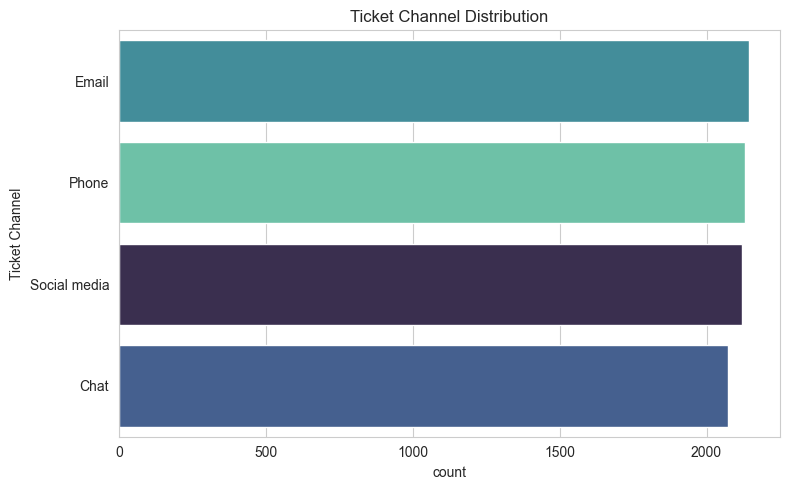

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Mean satisfaction by channel (closed tickets):
Ticket Channel
Chat            3.083086
Social media    2.969298
Email           2.963889
Phone           2.952243
Name: Customer Satisfaction Rating, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, y="Ticket Channel", order=df["Ticket Channel"].value_counts().index, hue="Ticket Channel", ax=ax, palette="mako", legend=False)
ax.set_title("Ticket Channel Distribution")
plt.tight_layout()
plt.savefig("../reports/eda_channel_distribution.png", dpi=120)
plt.show()

print(df["Ticket Channel"].value_counts())

# Channel vs satisfaction - business-relevant cross-analysis
print("\nMean satisfaction by channel (closed tickets):")
print(closed_df.groupby("Ticket Channel")["Customer Satisfaction Rating"].mean().sort_values(ascending=False))

## 7. Text length distributions

Relevant for the NLP tasks later - tells us how much text the models will actually
have to work with.

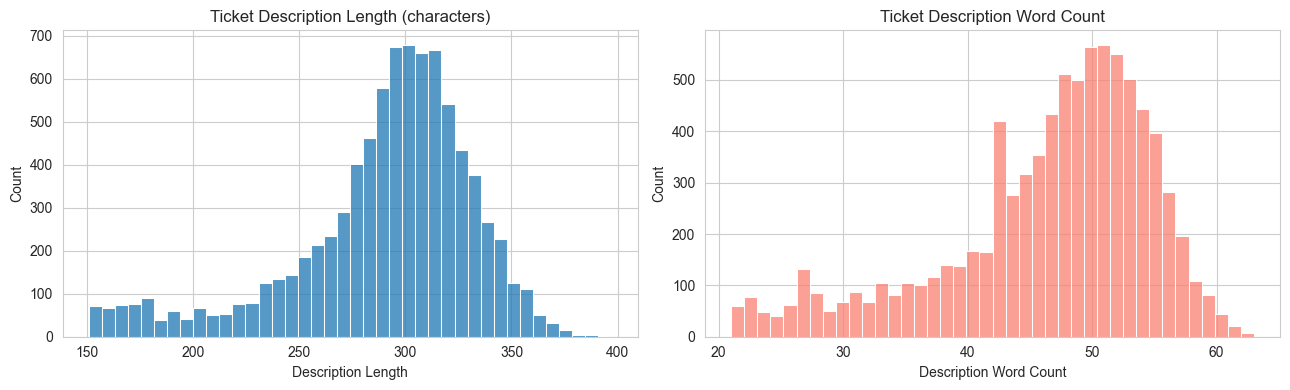

count    8469.000000
mean      289.821939
std        43.593954
min       151.000000
25%       273.000000
50%       298.000000
75%       318.000000
max       397.000000
Name: Description Length, dtype: float64


In [10]:
df["Description Length"] = df["Ticket Description"].str.len()
df["Subject Length"] = df["Ticket Subject"].str.len()
df["Description Word Count"] = df["Ticket Description"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["Description Length"], bins=40, ax=axes[0])
axes[0].set_title("Ticket Description Length (characters)")
sns.histplot(df["Description Word Count"], bins=40, ax=axes[1], color="salmon")
axes[1].set_title("Ticket Description Word Count")
plt.tight_layout()
plt.savefig("../reports/eda_text_length_distribution.png", dpi=120)
plt.show()

print(df["Description Length"].describe())

## 8. Word clouds — Ticket Subject and Ticket Description

**Honest observation to flag now, before we build any NLP model:** looking at the
raw text (see Step 1's dataset inspection), many descriptions contain unfilled
template placeholders like `{product_purchased}`. This word cloud will likely show
this - worth noting as a known characteristic of this dataset, not a preprocessing
bug on our part.

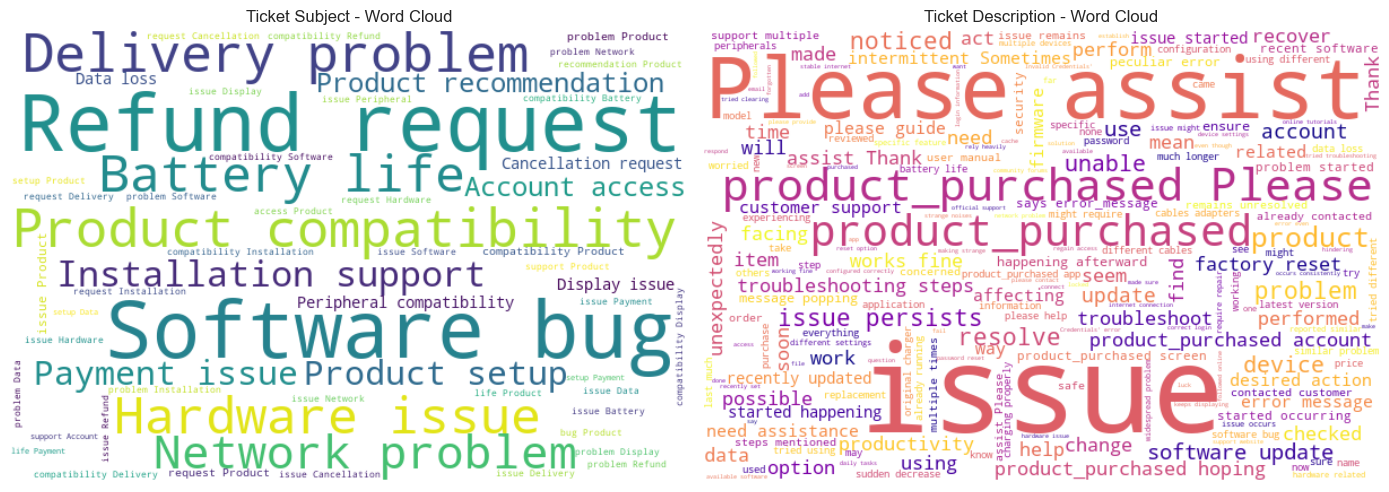

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

subject_text = " ".join(df["Ticket Subject"].dropna().astype(str))
subject_wc = WordCloud(width=600, height=400, background_color="white", colormap="viridis").generate(subject_text)
axes[0].imshow(subject_wc, interpolation="bilinear")
axes[0].set_title("Ticket Subject - Word Cloud")
axes[0].axis("off")

description_text = " ".join(df["Ticket Description"].dropna().astype(str))
description_wc = WordCloud(width=600, height=400, background_color="white", colormap="plasma").generate(description_text)
axes[1].imshow(description_wc, interpolation="bilinear")
axes[1].set_title("Ticket Description - Word Cloud")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../reports/eda_wordclouds.png", dpi=120)
plt.show()

## 9. Summary of EDA findings

**Key findings to carry forward into preprocessing and modeling:**

1. **Ticket Type has 5 classes, not 4** as the brief's problem statement describes -
   proceeding with the real 5 (Refund request, Technical issue, Cancellation request,
   Product inquiry, Billing inquiry), all reasonably balanced.
2. **Ticket Priority is well-balanced** across its 4 levels (Low/Medium/High/Critical).
3. **Resolution/Satisfaction/Time-to-Resolution data only exists for closed tickets**
   (2,769 of 8,469 rows) - the regression and satisfaction-related analysis must be
   scoped to this subset only.
4. **Some resolution times are negative** (data quality issue) - needs filtering
   before the regression task.
5. **Ticket text contains unfilled template placeholders** (e.g. `{product_purchased}`)
   - a known characteristic of this synthetic dataset. This may limit how strongly
   the text content can predict Ticket Type/Priority, since descriptions appear to
   follow generic templates rather than being strongly differentiated per category.